<a href="https://colab.research.google.com/github/Zeeba1705/atml_PA0/blob/main/Task4_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 4: VAE

###4.1: Building a Basic VAE in PyTorch:

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform= transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

batch_size= 128

train_loader= DataLoader(train_data, batch_size=batch_size,shuffle=True)

test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [4]:
class VAE(nn.Module):

    def __init__(self, latent_dim=2):
        super().__init__()

        self.fc1= nn.Linear(784, 400)
        self.fc_mean= nn.Linear(400, latent_dim)
        self.fc_logvar= nn.Linear(400, latent_dim)

        self.fc2= nn.Linear(latent_dim, 400)
        self.fc3= nn.Linear(400, 784)


    def encode(self, x):

        x= x.view(-1, 784)
        h = F.relu(self.fc1(x))

        mean= self.fc_mean(h)
        logvar = self.fc_logvar(h)

        return mean, logvar


    def reparameterize(self, mean, logvar):

        std= torch.exp(0.5 * logvar)
        eps= torch.randn_like(std)

        z= mean+ eps * std

        return z


    def decode(self, z):

        h= F.relu(self.fc2(z))
        reconstructed= torch.sigmoid(self.fc3(h))

        return reconstructed


    def forward(self, x):

        mean, logvar= self.encode(x)
        z = self.reparameterize(mean, logvar)
        reconstructed= self.decode(z)

        return reconstructed, mean, logvar

In [6]:
latent_dim = 2

model= VAE(latent_dim=latent_dim).to(device)

print(model)

images, labels = next(iter(train_loader))

images = images.to(device)

recon, mu, logvar = model(images)

print("Input shape:", images.shape)
print("Reconstruction shape:", recon.shape)
print("Mu shape:", mu.shape)
print("Logvar shape:", logvar.shape)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mean): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
)
Input shape: torch.Size([128, 1, 28, 28])
Reconstruction shape: torch.Size([128, 784])
Mu shape: torch.Size([128, 2])
Logvar shape: torch.Size([128, 2])


In [7]:
def vae_loss(reconstructed, x, mu, logvar):
    x= x.view(-1, 784)

    recon_loss= F.binary_cross_entropy(reconstructed,x, reduction="sum")

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss= recon_loss + kl_loss

    return total_loss, recon_loss, kl_loss

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs= 10

train_losses= []
recon_losses= []
kl_losses= []

for epoch in range(num_epochs):

    model.train()

    total_loss= 0
    total_recon= 0
    total_kl= 0

    for images, _ in train_loader:

        images= images.to(device)

        optimizer.zero_grad()

        recon, mu, logvar= model(images)

        loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar)

        loss.backward()

        optimizer.step()

        total_loss+= loss.item()
        total_recon+= recon_loss.item()
        total_kl+= kl_loss.item()

    avg_loss= total_loss / len(train_data)
    avg_recon= total_recon / len(train_data)
    avg_kl= total_kl / len(train_data)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Recon: {avg_recon:.4f} | "
        f"KL: {avg_kl:.4f}"
    )

Epoch 1/10 | Loss: 190.1877 | Recon: 184.1902 | KL: 5.9976
Epoch 2/10 | Loss: 167.9376 | Recon: 162.6220 | KL: 5.3155
Epoch 3/10 | Loss: 163.1348 | Recon: 157.7208 | KL: 5.4140
Epoch 4/10 | Loss: 160.6145 | Recon: 155.1179 | KL: 5.4966
Epoch 5/10 | Loss: 158.9556 | Recon: 153.4138 | KL: 5.5418
Epoch 6/10 | Loss: 157.6787 | Recon: 152.0678 | KL: 5.6110
Epoch 7/10 | Loss: 156.6446 | Recon: 150.9937 | KL: 5.6509
Epoch 8/10 | Loss: 155.8470 | Recon: 150.1517 | KL: 5.6952
Epoch 9/10 | Loss: 155.0958 | Recon: 149.3570 | KL: 5.7387
Epoch 10/10 | Loss: 154.4161 | Recon: 148.6382 | KL: 5.7779


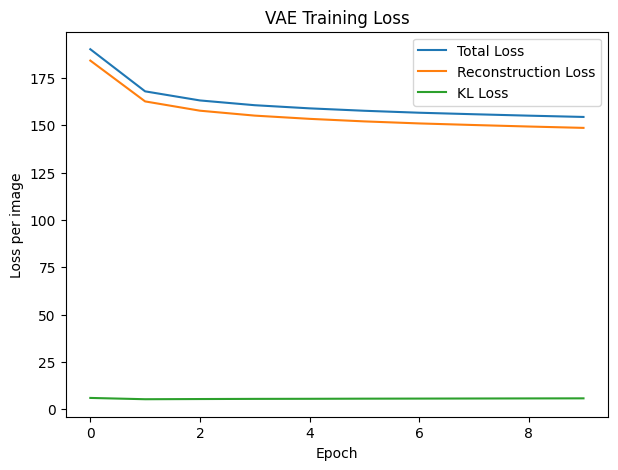

In [9]:
plt.figure(figsize=(7, 5))

plt.plot(train_losses, label="Total Loss")
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss per image")
plt.title("VAE Training Loss")
plt.legend()

plt.show()

###4.2: Analyzing VAE Performance

In [10]:
#latent space visualisation:
model.eval()

latent_points= []
latent_labels= []

with torch.no_grad():
    for images, labels in test_loader:
        images= images.to(device)

        mu, logvar= model.encode(images)

        latent_points.append(mu.cpu())
        latent_labels.append(labels)

latent_points= torch.cat(latent_points, dim=0).numpy()
latent_labels= torch.cat(latent_labels, dim=0).numpy()

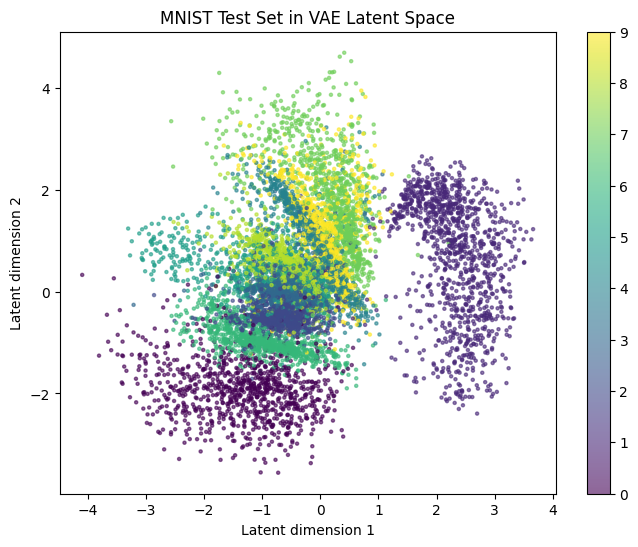

In [11]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=latent_labels,
    s=5,
    alpha=0.6
)

plt.colorbar(scatter, ticks=range(10))
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("MNIST Test Set in VAE Latent Space")

plt.show()

In [12]:
model.eval()

images, labels = next(iter(test_loader))
images= images.to(device)

with torch.no_grad():
    recon, mu, logvar = model(images)

recon= recon.view(-1, 1, 28, 28)

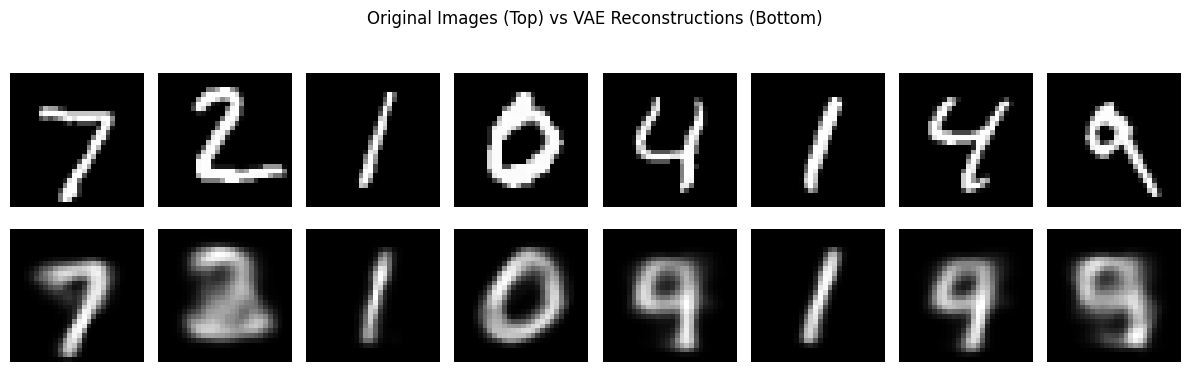

In [13]:
num_images = 8

plt.figure(figsize=(12, 4))

for i in range(num_images):

    plt.subplot(2, num_images, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(2, num_images, num_images + i + 1)
    plt.imshow(recon[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Original Images (Top) vs VAE Reconstructions (Bottom)")
plt.tight_layout()
plt.show()

In [14]:
model.eval()

num_samples= 10

with torch.no_grad():

    z= torch.randn(num_samples, latent_dim, device=device)

    generated= model.decode(z)

    generated= generated.view(-1, 1, 28, 28)

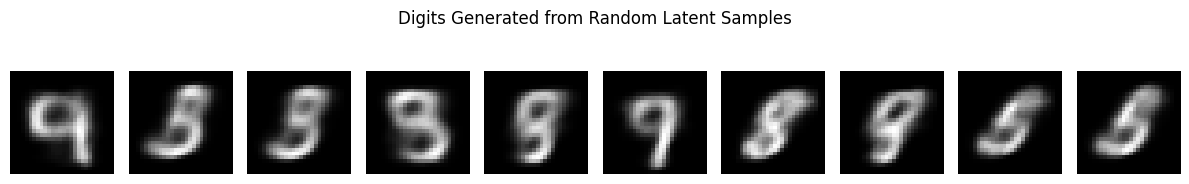

In [15]:
plt.figure(figsize=(12, 2))

for i in range(num_samples):

    plt.subplot(1, num_samples, i + 1)

    plt.imshow(
        generated[i].cpu().squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Digits Generated from Random Latent Samples")
plt.tight_layout()
plt.show()